In [1]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader,Dataset
from matplotlib import pyplot as plt
import os
import cv2
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cpu


In [2]:
class CustomImageDataset(Dataset):
    def __init__(self):
        self.images = []
        self.masks = []
        for root, folders, files in os.walk("mri"):
            for file in files:
                if file.endswith("_mask.tif"):
                    mask_name = file
                    image_name = file.removesuffix("_mask.tif") + ".tif"

                    image_path = os.path.join(root, image_name)
                    self.images.append(image_path)

                    mask_path = os.path.join(root, mask_name)
                    self.masks.append(mask_path)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = self.masks[idx]

        image = torch.from_numpy(cv2.imread(img_path, cv2.IMREAD_UNCHANGED)).permute(2, 0, 1).to(torch.float32) / 255
        mask = torch.from_numpy(cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)).unsqueeze(0).to(torch.float32) / 255
        return image, mask

In [3]:
dataset = CustomImageDataset()
train_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

torch.Size([8, 4, 256, 256]) torch.Size([8, 1, 256, 256]) torch.Size([8, 3, 256, 256])


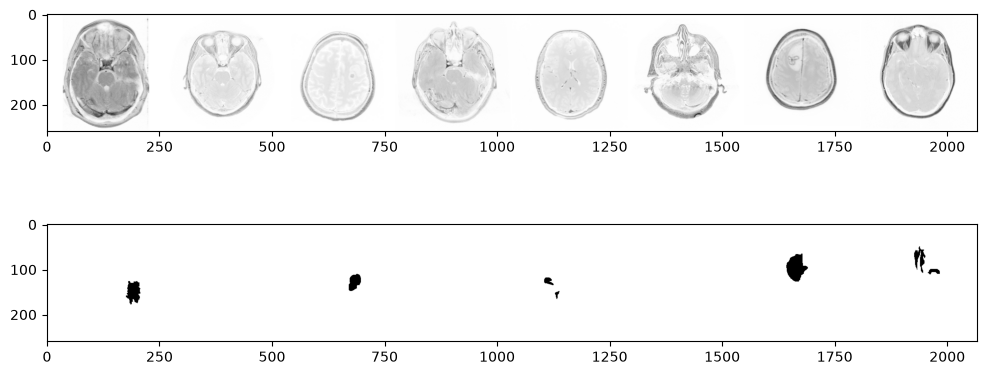

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
x, y = next(iter(train_dataloader))
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap='Greys');
axs[1].imshow(torchvision.utils.make_grid(y)[0], cmap='Greys');

merged = torch.cat([x,y], dim=1)
print(merged.size(),y.size(),x.size())

In [5]:
def corrupt(x, amount):
  """Corrupt the input `x` by mixing it with noise according to `amount`"""
  noise = torch.rand_like(x)
  amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
  return  x * (1-amount) +  noise * amount

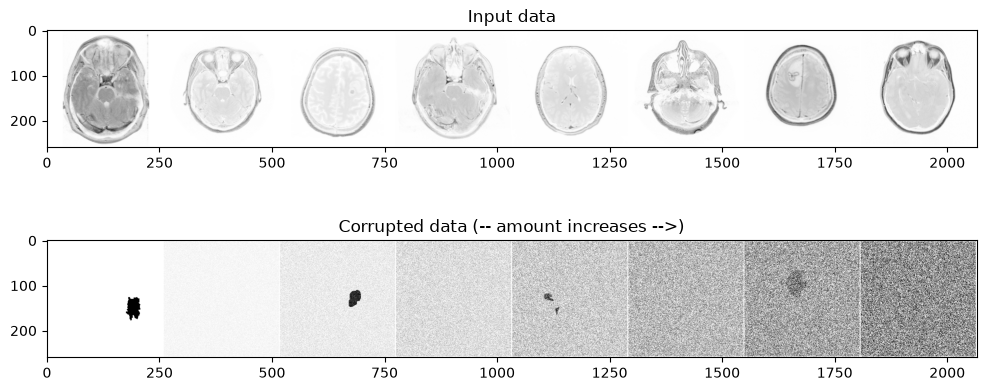

In [6]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x, value_range=(0, 1))[0], cmap='Greys')

# Adding noise
amount = torch.linspace(0, 1, x.shape[0]) # Left to right -> more corruption
noised_y = corrupt(y, amount)

# Plotting the noised version
axs[1].set_title('Corrupted data (-- amount increases -->)')
axs[1].imshow(torchvision.utils.make_grid(noised_y, normalize=True,value_range=(0, 1))[0], cmap='Greys');

In [7]:
class BasicUNet(nn.Module):
    """A minimal UNet implementation."""
    def __init__(self, in_channels=4, out_channels=1):
        super().__init__()
        self.down_layers = torch.nn.ModuleList([ 
            nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
        ])
        self.up_layers = torch.nn.ModuleList([
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2), 
        ])
        self.act = nn.SiLU() # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x)) # Through the layer and the activation function
            if i < 2: # For all but the third (final) down layer:
              h.append(x) # Storing output for skip connection
              x = self.downscale(x) # Downscale ready for the next layer
              
        for i, l in enumerate(self.up_layers):
            if i > 0: # For all except the first up layer
              x = self.upscale(x) # Upscale
              x += h.pop() # Fetching stored output (skip connection)
            x = l(x)
            if i < len(self.up_layers) -1:
                x = self.act(x) # Through the layer and the activation function
            
        return x

In [8]:
net = BasicUNet()
x = torch.rand(2, 4, 32, 32)
net(x).shape

torch.Size([2, 1, 32, 32])

In [9]:
class diceloss(torch.nn.Module):
    # https://discuss.pytorch.org/t/implementation-of-dice-loss/53552
    def init(self):
        super(diceloss, self).init()
    def forward(self,pred, target):
        smooth = 1.
        
        # pred = torch.softmax(pred, dim=1)[:, 1, ...]

        iflat = pred.contiguous().view(-1)
        tflat = target.contiguous().view(-1)
        
        intersection = (iflat * tflat).sum()
        A_sum = torch.sum(iflat * iflat)
        B_sum = torch.sum(tflat * tflat)
        return 1 - ((2. * intersection + smooth) / (A_sum + B_sum + smooth) )

100%|██████████| 246/246 [09:06<00:00,  2.22s/it]


Finished epoch 0. Average loss for this epoch: 0.231736


100%|██████████| 246/246 [08:48<00:00,  2.15s/it]


Finished epoch 1. Average loss for this epoch: 0.168802


100%|██████████| 246/246 [08:49<00:00,  2.15s/it]


...

Finished epoch 7. Average loss for this epoch: 0.091743


100%|██████████| 246/246 [08:47<00:00,  2.14s/it]


Finished epoch 8. Average loss for this epoch: 0.083053


100%|██████████| 246/246 [09:53<00:00,  2.41s/it]

Finished epoch 9. Average loss for this epoch: 0.070862


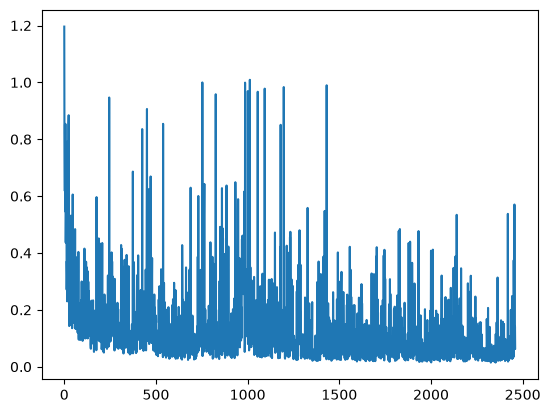

In [10]:
# Dataloader (you can mess with batch size)
batch_size = 16
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# How many runs through the data should we do?
n_epochs = 10

# Create the network
net = BasicUNet()
net.to(device)

# Our loss function
loss_fn = diceloss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3) 

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):
    for x, y in tqdm(train_dataloader):

        # Get some data and prepare the corrupted version
        x = x.to(device) # Data on the GPU
        y = y.to(device) # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device) # Pick random noise amounts
        noisy_y = corrupt(y, noise_amount) # Create our noisy x

        merged = torch.cat([x,noisy_y],dim=1)
        # Get the model prediction
        pred = net(merged)

        # Calculate the loss
        loss = loss_fn(pred, y) # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# View the loss curve
plt.plot(losses)

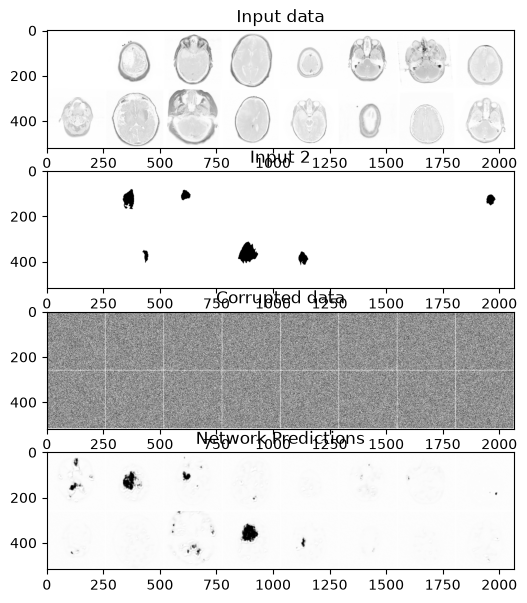

In [17]:
#@markdown Visualizing model predictions on noisy inputs:

# Fetch some data
x, y = next(iter(train_dataloader))
x = x[:16] # Only using the first 8 for easy plotting

# Corrupt with a range of amounts
noise_amount = torch.linspace(1, 1, x.shape[0]) # Left to right -> more corruption
noisy_y = corrupt(y, noise_amount) # Create our noisy x

merged = torch.cat([x,noisy_y],dim=1)
# Get the model prediction


# Get the model predictions
with torch.no_grad():
  preds = net(merged).detach().cpu()

# Plot
fig, axs = plt.subplots(4, 1, figsize=(16, 7))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0].clip(0, 1), cmap='Greys')
axs[1].set_title('Input 2')
axs[1].imshow(torchvision.utils.make_grid(y)[0].clip(0, 1), cmap='Greys')
axs[2].set_title('Corrupted data')
axs[2].imshow(torchvision.utils.make_grid(noisy_y)[0].clip(0, 1), cmap='Greys')
axs[3].set_title('Network Predictions')
axs[3].imshow(torchvision.utils.make_grid(preds)[0].clip(0, 1), cmap='Greys');